In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.22540771/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# c1 - First look

In [14]:
logN_dict = {'HI':'14.00, -0.08, +0.08',
        'HeI':'<13.0',
        'CII':'<13.5',
        'CIII':'<12.9',
        'CIV':'12.70, -0.06, +0.06',
        'NII':'<13.4',
        'NIII':'<13.1',
        'NIV':'<12.7',
        'NV':'<13.4',
        'OII':'<13.9',
        'OIII':'<13.4',
        'OIV':'13.90, -0.04, +0.04',
        'OV':'14.23, -0.02, +0.02',
        'OVI':'14.12, -0.06, +0.06',
        'NeV':'<13.4',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<14.0',
        'MgX':'<13.8',
        'AlII':'<11.2',
        'AlIII':'<11.6',
        'SiII':'<14.0',
        'SiIII':'<12.1',
        'SiIV':'<12.4',
        'SIV':'<12.9',
        'SV':'<12.5',
        'SVI':'<13.3',
        'FeII':'<11.8',}

# c1 - Single-phase density solution

In [15]:
logN_dict = {#'HI':'14.00, -0.08, +0.08',
        #'HeI':'<13.0',
        #'CII':'<13.5',
        #'CIII':'<12.9',
        #'CIV':'12.70, -0.06, +0.06',
        #'NII':'<13.4',
        #'NIII':'<13.1',
        #'NIV':'<12.7',
        #'NV':'<13.4',
        #'OII':'<13.9',
        'OIII':'<13.4',
        'OIV':'13.90, -0.04, +0.04',
        'OV':'14.23, -0.02, +0.02',
        'OVI':'14.12, -0.06, +0.06',}
        #'NeV':'<13.4',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        #'MgII':'<14.0',
        #'MgX':'<13.8',
        #'AlII':'<11.2',
        #'AlIII':'<11.6',
        #'SiII':'<14.0',
        #'SiIII':'<12.1',
        #'SiIV':'<12.4',
        #'SIV':'<12.9',
        #'SV':'<12.5',
        #'SVI':'<13.3',
        #'FeII':'<11.8',}

In [16]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OV'])

'-0.11, -0.06, 0.06'

In [17]:
logN_ratio_dict = {'OV/OIV': '0.33, -0.04, 0.04',
                   'OVI/OV': '-0.11, -0.06, 0.06'}

(-2.2, 2.5)

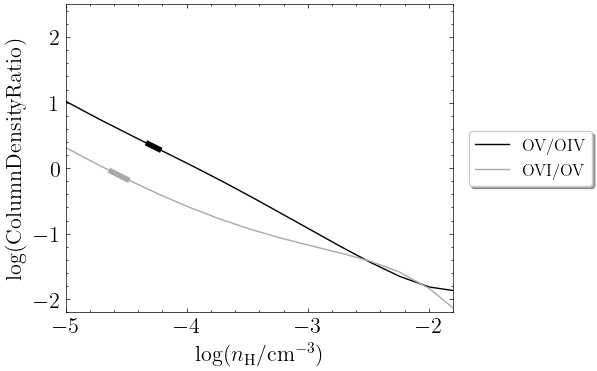

In [18]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

# c1 - Single phase solution

In [14]:
def lambda_log_prior(params):
    
    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C':C_O}])
    
    return log_prior(params_full)

In [15]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C':C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [16]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

In [17]:
logN_dict = {#'HI':'14.00, -0.08, +0.08',
        #'HeI':'<13.0',
        'CII':'<13.5',
        'CIII':'<12.9',
        'CIV':'12.70, -0.06, +0.06',
        #'NII':'<13.4',
        #'NIII':'<13.1',
        #'NIV':'<12.7',
        #'NV':'<13.4',
        'OII':'<13.9',
        'OIII':'<13.4',
        'OIV':'13.90, -0.04, +0.04',
        'OV':'14.23, -0.02, +0.02',
        #'OVI':'14.12, -0.06, +0.06',}
        #'NeV':'<13.4',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<14.0',
        #'MgX':'<13.8',
        #'AlII':'<11.2',
        #'AlIII':'<11.6',
        'SiII':'<14.0',}
        #'SiIII':'<12.1',
        #'SiIV':'<12.4',
        #'SIV':'<12.9',
        #'SV':'<12.5',
        #'SVI':'<13.3',
        #'FeII':'<11.8',}

In [18]:
logN_HI_test = 14.0
log_hdens_test = -4.1
log_metals_test = -0.7
C_O_test = -0.5

In [19]:
#species_logN_interp['Si+2']([logN_HI_test, log_hdens_test_p1, log_metals_test_p1])[0]

In [20]:
logN_species_test = np.array(predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp, {'C':C_O_test}))

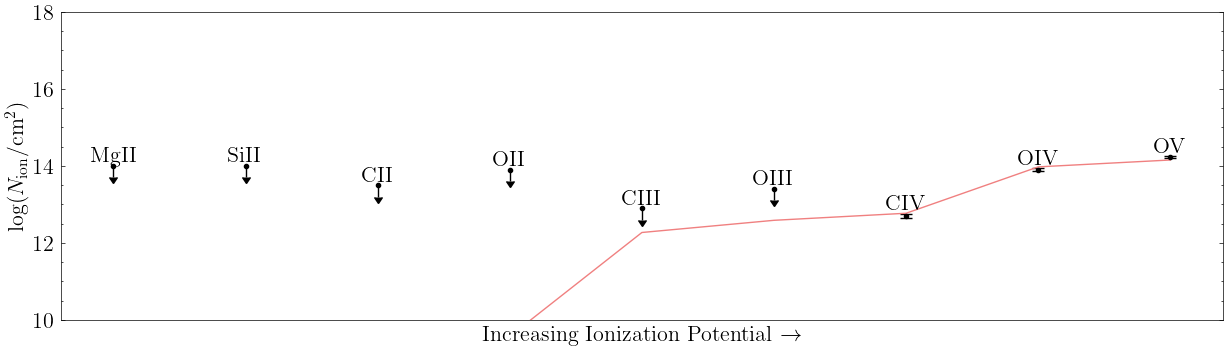

In [21]:
fig, ax = plot_column_densities_obs(logN_dict)
#ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='skyblue')
#ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='gold')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral')

In [22]:
pos = np.array([log_hdens_test, log_metals_test, C_O_test]) + 1e-7 * np.random.randn(200, 3)
nwalkers, ndim = pos.shape

In [23]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [24]:
#species_logN_interp['S+5']([16.67, 0.1, -0.6]), species_logN_interp['S+5']([14.9, -2.7, -1.0]), species_logN_interp['S+5']([14.9, -3.7, -1.0])

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals', 'C_O'])
#flat_samples.to_csv(savedir+'one_phase_c1.csv', index=False)

flat_samples = pd.read_csv(savedir+'one_phase_c1.csv')

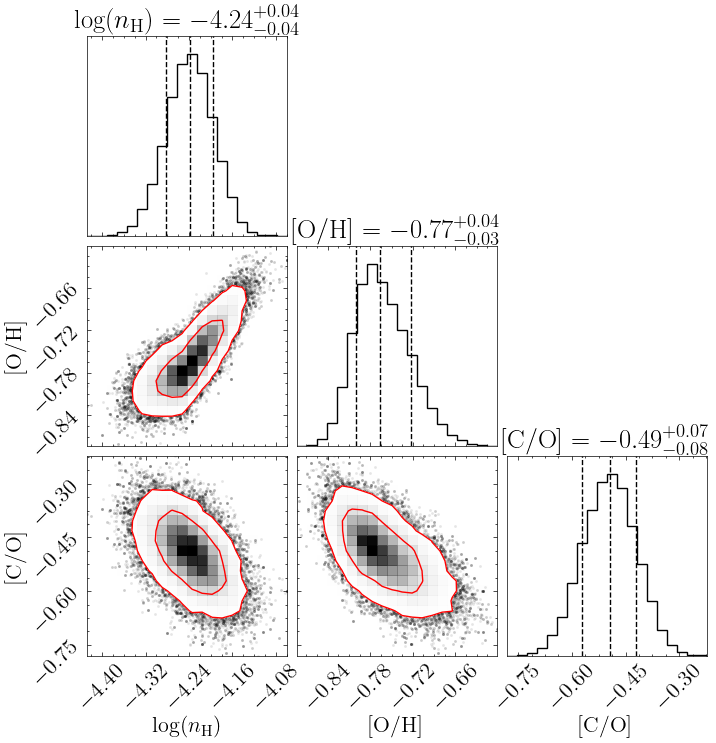

In [27]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$', r'$[\mathrm{N/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [28]:
logN_dict = {#'HI':'14.00, -0.08, +0.08',
        #'HeI':'<13.0',
        #'CII':'<13.5',
        'CIII':'<12.9',
        'CIV':'12.70, -0.06, +0.06',
        #'NII':'<13.4',
        'NIII':'<13.1',
        'NIV':'<12.7',
        'NV':'<13.4',
        #'OII':'<13.9',
        'OIII':'<13.4',
        'OIV':'13.90, -0.04, +0.04',
        'OV':'14.23, -0.02, +0.02',
        'OVI':'14.12, -0.06, +0.06',
        'NeV':'<13.4',
        'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        #'MgII':'<14.0',
        #'MgX':'<13.8',
        #'AlII':'<11.2',
        #'AlIII':'<11.6',
        #'SiII':'<14.0',
        'SiIII':'<12.1',
        'SiIV':'<12.4',
        'SIV':'<12.9',
        'SV':'<12.5',
        'SVI':'<13.3',}
        #'FeII':'<11.8',}

In [29]:
b_dict = {'HI':'25, -4, +4',
          'CIV':'17, -2, +3',
          'OIV':'30, -4, +4',
          'OV':'31, -1, +2',
          'OVI':'23, -3, +3'}

In [30]:
sample_indices_one_phase = np.random.randint(low=0, high=len(flat_samples), size=500)

In [31]:
z_sys = 1.22540771

In [32]:
import matplotlib.lines as mlines

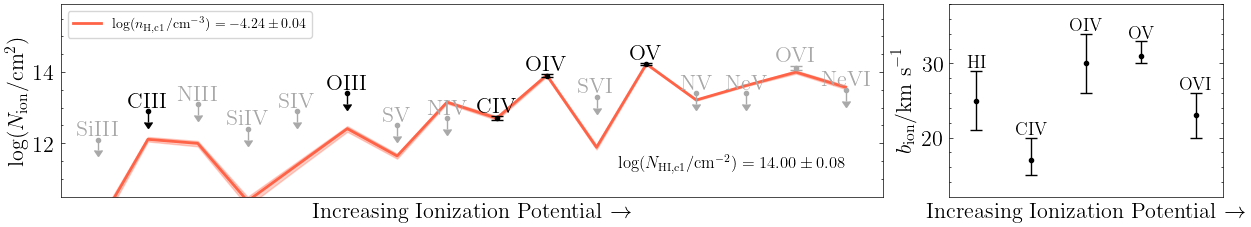

In [33]:
logN_species_grid = np.zeros((len(logN_dict), len(sample_indices_one_phase)))

fig, axes = plt.subplots(1, 2, figsize=(15,2.5), gridspec_kw={'width_ratios': [3, 1]})

for i in range(len(sample_indices_one_phase)):
    
    idx = sample_indices_one_phase[i]
    flat_samples_row = flat_samples.iloc[i]
    
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = np.array(predict_col_dens(logN_dict, logN_HI_test,  log_hdens, log_metals, 
                                                     species_logN_interp,{'C':C_O}))

    logN_species_grid[:,i] = logN_species_test
    
logN_species_med = np.median(logN_species_grid, axis=1)
logN_species_lo = np.percentile(logN_species_grid, 100*(1-cdf_1sig), axis=1)
logN_species_hi = np.percentile(logN_species_grid, 100*cdf_1sig, axis=1)

axes[0].fill_between(np.arange(len(logN_species_test)), logN_species_lo, logN_species_hi,
                color='tomato', alpha=.3)
axes[0].plot(np.arange(len(logN_species_test)), logN_species_med, color='tomato', lw=2, alpha=1)

    
plot_column_densities_obs(logN_dict, fig, axes[0],
                          gray_out = ['NV', 'OVI', 'SiIII', 
                                      'SiIV', 'SIV', 'SV', 'SVI',
                                     'NeV', 'NeVI', 'MgII'
                                     'NII', 'NIII', 'NIV', 'NV'])

axes[0].set_ylim(10.5,15.9)

axes[0].text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c1}/\mathrm{cm}^{-2}) = 14.00 \pm 0.08$', fontsize=12,
            horizontalalignment='right')

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='tomato', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H,c1}/\mathrm{cm}^{-3}) = -4.24 \pm 0.04$'))

axes[0].legend(handles=handles, loc='upper left', fontsize=10)

plt.subplots_adjust(wspace=0.12, hspace=0)   

plot_linewidth_obs(b_dict, fig, axes[1], fs=13)#, gray_out = ['OVI'])
axes[1].set_xlim(-0.5,len(b_dict)-1+.5)
axes[1].set_ylim(12,38)
#ax.set_title('Two-phase decomposition for a CIV absorber', fontsize=18)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_cloudy_c1.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

Get cloud sizes

In [52]:
l = np.zeros(len(flat_samples))

In [53]:
for i in range(len(l)):
    
    flat_samples_row = flat_samples.iloc[i]
    
    l[i] = get_cloud_size(logN_HI_test, flat_samples_row['log_hdens'], species_logN_interp)

Text(0, 0.5, 'Counts')

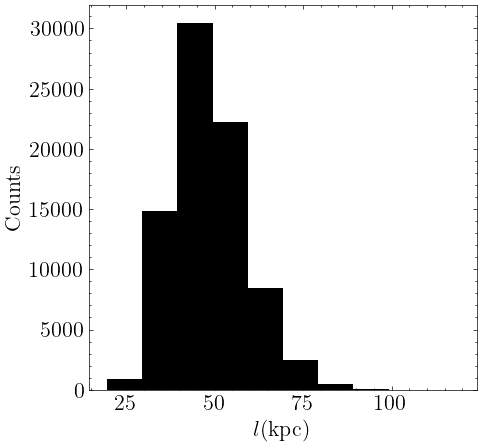

In [54]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l, bins=10)

ax.set_xlabel(r'$l (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [55]:
np.median(l), np.median(l)-np.percentile(l, 100*(1-cdf_1sig)), np.percentile(l, 100*cdf_1sig)-np.median(l)

(47.372792697399056, 9.118650800959564, 11.247186186990575)